<a href="https://colab.research.google.com/github/TLambert06/public-utility-regression-model/blob/main/public_utility_regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format='{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

HS_data['date'] = pd.to_datetime(HS_data['date'])

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
#Create spring dummy variable and interaction term
HS_data['spring_DV'] = np.where(HS_data['date'].dt.month.isin([3,4,5]),1,0)
HS_data['spring_interaction'] = HS_data['production'] * HS_data['spring_DV']

In [ ]:
#Create summer dummy variable and interaction term
HS_data['summer_DV'] = np.where(HS_data['date'].dt.month.isin([6,7,8]),1,0)
HS_data['summer_interaction'] = HS_data['production'] * HS_data['summer_DV']

In [ ]:
#Display new variables
display(HS_data)

,type,date,revenue,production,coolDD,heatDD,spring_DV,spring_interaction,summer_DV,summer_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,0,0,0,0
1,dt4training,2011-02-28,24552000,686144,0,794,0,0,0,0
2,dt4training,2011-03-31,14804728,416464,0,714,1,416464,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,1,324456,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,1,151104,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0,1,479264
6,dt4training,2011-07-31,13617528,708472,486,0,0,0,1,708472
7,dt4training,2011-08-31,14092512,687728,346,0,0,0,1,687728
8,dt4training,2011-09-30,12085472,567424,195,19,0,0,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0,0,0


In [ ]:
#split training and testing data
dt4training = HS_data.loc[HS_data['type'] == 'dt4training']
dt4testing = HS_data.loc[HS_data['type'] == 'dt4testing']

display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,spring_DV,spring_interaction,summer_DV,summer_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,0,0,0,0
37,dt4testing,2014-02-28,26792280,714128,0,938,0,0,0,0
38,dt4testing,2014-03-31,19935840,805600,0,866,1,805600,0,0
39,dt4testing,2014-04-30,13468000,375856,0,412,1,375856,0,0
40,dt4testing,2014-05-31,7344128,279296,49,88,1,279296,0,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,1,517600
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,1,749472
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,1,663432
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,0,0
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,0,0


In [ ]:
# train the spring model
y_spring = dt4training.loc[:,'revenue']
x_spring = dt4training.loc[:,['production','spring_DV','spring_interaction']]
x_spring = sm.add_constant(x_spring)

model_spring = sm.OLS(y_spring,x_spring).fit()

model_spring.params

,0
const,5645359.67
production,17.00
spring_DV,-6781361.28
spring_interaction,23.65


In [ ]:
# test the spring model and prepare to find the MAPE score
x_spring_test = dt4testing.loc[:,['production','spring_DV','spring_interaction']]
x_spring_test = sm.add_constant(x_spring_test)

model_spring_assessment = dt4testing.copy()

model_spring_assessment['model_spring_predicted_revenue'] = model_spring.predict(x_spring_test)

model_spring_assessment['model_spring_abs_pct_error'] = abs(
    (model_spring_assessment['revenue']-model_spring_assessment['model_spring_predicted_revenue']
     )/model_spring_assessment['revenue'])

display(model_spring_assessment)

,type,date,revenue,production,coolDD,heatDD,spring_DV,spring_interaction,summer_DV,summer_interaction,model_spring_predicted_revenue,model_spring_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,0,0,0,0,15954706.09,0.17
37,dt4testing,2014-02-28,26792280,714128,0,938,0,0,0,0,17786179.17,0.34
38,dt4testing,2014-03-31,19935840,805600,0,866,1,805600,0,0,31615584.53,0.59
39,dt4testing,2014-04-30,13468000,375856,0,412,1,375856,0,0,14144385.88,0.05
40,dt4testing,2014-05-31,7344128,279296,49,88,1,279296,0,0,10218748.89,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,1,517600,14445026.08,0.29
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,1,749472,18387059.02,0.32
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,1,663432,16924301.49,0.37
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,0,0,17574143.93,0.39
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,0,0,12645106.68,0.35


In [ ]:
# train the summer model
y_summer = dt4training.loc[:,'revenue']
x_summer = dt4training.loc[:,['production','summer_DV','summer_interaction']]
x_summer = sm.add_constant(x_summer)

model_summer = sm.OLS(y_summer,x_summer).fit()

model_summer.params

,0
const,1244884.00
production,30.40
summer_DV,4207869.63
summer_interaction,-17.81


In [ ]:
# test the spring model and prepare to find the MAPE score
x_summer_test = dt4testing.loc[:,['production','summer_DV','summer_interaction']]
x_summer_test = sm.add_constant(x_summer_test)

model_summer_assessment = dt4testing.copy()

model_summer_assessment['model_summer_predicted_revenue'] = model_summer.predict(x_summer_test)

model_summer_assessment['model_summer_abs_pct_error'] = abs(
    (model_summer_assessment['revenue']-model_summer_assessment['model_summer_predicted_revenue']
     )/model_summer_assessment['revenue'])

display(model_spring_assessment)

,type,date,revenue,production,coolDD,heatDD,spring_DV,spring_interaction,summer_DV,summer_interaction,model_spring_predicted_revenue,model_spring_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,0,0,0,0,15954706.09,0.17
37,dt4testing,2014-02-28,26792280,714128,0,938,0,0,0,0,17786179.17,0.34
38,dt4testing,2014-03-31,19935840,805600,0,866,1,805600,0,0,31615584.53,0.59
39,dt4testing,2014-04-30,13468000,375856,0,412,1,375856,0,0,14144385.88,0.05
40,dt4testing,2014-05-31,7344128,279296,49,88,1,279296,0,0,10218748.89,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,1,517600,14445026.08,0.29
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,1,749472,18387059.02,0.32
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,1,663432,16924301.49,0.37
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,0,0,17574143.93,0.39
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,0,0,12645106.68,0.35


In [ ]:
#spring MAPE score
model_spring_assessment['model_spring_abs_pct_error'].mean()

np.float64(0.2892751835381226)

In [ ]:
#summer MAPE score
model_summer_assessment['model_summer_abs_pct_error'].mean()

np.float64(0.19680284631043443)

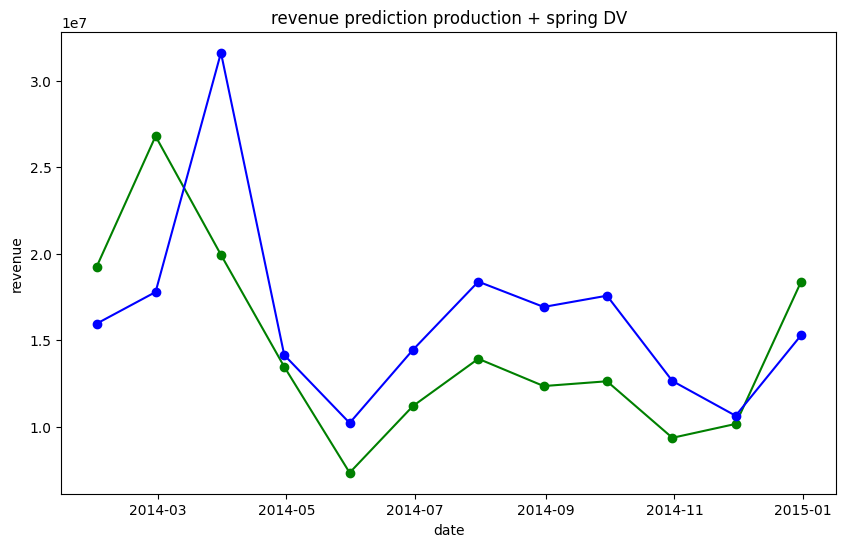

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue prediction production + spring DV')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model_spring_assessment['date'], model_spring_assessment['revenue'], marker='o', color='green')
plt.plot(model_spring_assessment['date'], model_spring_assessment['model_spring_predicted_revenue'], marker='o', color='blue')

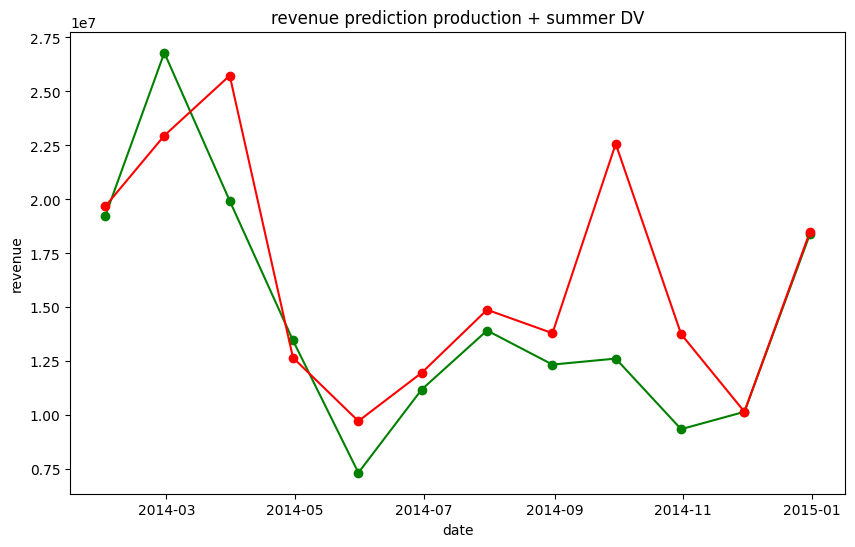

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue prediction production + summer DV')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model_summer_assessment['date'], model_summer_assessment['revenue'], marker='o', color='green')
plt.plot(model_summer_assessment['date'], model_summer_assessment['model_summer_predicted_revenue'], marker='o', color='red')

# Memo
To: Hotazel Steam
From: Analyst
Date: July 17, 2026
Re: Comparison of revenue forecasting models using dummy variables

Bottom Line:
The two regression models we're built using production as the independant variable and each with a seasonl dummy variable. The summer model is roughly 10% better than the spring model.

Scope:
This memo covers the analysis of Hotazel Steam's data to produce a predictive model using exisiting variables such as production and new dummy variables such as spring and summer.

Methodology:
To perform this analysis the data was first split into training and testing. Then the spring and summer dummay variables we're created. The a regression model was created for each from dummy variable.

Key Findings:
We found the MAPE score was roughly 10% better for the summer model.

Reccomendation
We reccomend Hotazel Steam use summer as the dummy variable to predict revenue. This is likely a better indicator since people tend to use AC in the summer, which would drive more revenue for Hotazel steam than the spring season.